# Customer Behavior Analysis — E-Commerce Dataset

350 customers, 11 columns. The goal is simple: figure out who's buying, what keeps them happy, and who's about to stop showing up.

---
## 1. Imports and Setup

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
sat_colors = {'Satisfied': '#55A868', 'Neutral': '#4C72B0', 'Unsatisfied': '#C44E52'}
sns.set_palette(PALETTE)

print('Ready.')

Ready.


---
## 2. Loading and Exploring the Data

### 2.1 Load the Dataset

In [38]:
df = pd.read_csv('ecommerce_customers.csv')
print(f'{df.shape[0]} rows, {df.shape[1]} columns')
df.head()

350 rows, 11 columns


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


### 2.2 Data Types and Basic Info

In [39]:
df.info()
print()
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB



,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.00,350.00,350.00,350.00,350.00,350.00
mean,275.50,33.60,845.38,12.60,4.02,26.59
std,101.18,4.87,362.06,4.16,0.58,13.44
min,101.00,26.00,410.80,7.00,3.00,9.00
25%,188.25,30.00,502.00,9.00,3.50,15.00
50%,275.50,32.50,775.20,12.00,4.10,23.00
75%,362.75,37.00,1160.60,15.00,4.50,38.00
max,450.00,43.00,1520.10,21.00,4.90,63.00


A few things stand out right away:

- Age is tight — 26 to 43, average around 34. This isn't a broad demographic spread; it's basically one generation.
- Total Spend has real variance ($410 to $1520), which is good — it means segmentation by spend will actually tell us something.
- Average Rating never drops below 3.0. That's either genuinely positive feedback or a floor in the data collection.
- Days Since Last Purchase goes up to 63. Customers at that end of the range are the ones worth worrying about.

### 2.3 Missing Values

In [40]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('No missing values found.')
else:
    print(missing_df)

null_sat = df['Satisfaction Level'].isna().sum()
print(f'\nSatisfaction Level — missing: {null_sat} rows ({null_sat/len(df)*100:.1f}%)')

                    Missing Count  Missing %
Satisfaction Level              2       0.57

Satisfaction Level — missing: 2 rows (0.6%)


Two rows are missing `Satisfaction Level` — 0.6% of the data. I'll fill both with the mode. Dropping them would be overkill for two records.

### 2.4 Cleaning the Data

In [41]:
df_clean = df.copy()

mode_sat = df_clean['Satisfaction Level'].mode()[0]
df_clean['Satisfaction Level'].fillna(mode_sat, inplace=True)
print(f'Filled {null_sat} missing value(s) in Satisfaction Level with: "{mode_sat}"')

numeric_cols = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']

print('\nOutlier check (IQR method):')
for col in numeric_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower    = Q1 - 1.5 * IQR
    upper    = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]
    print(f'  {col}: {outliers} outliers  [valid range: {lower:.1f} to {upper:.1f}]')

print('\nNo outliers found — keeping all 350 rows.')
print(f'Clean dataset: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns')

Filled 2 missing value(s) in Satisfaction Level with: "Satisfied"

Outlier check (IQR method):
  Age: 0 outliers  [valid range: 19.5 to 47.5]
  Total Spend: 0 outliers  [valid range: -485.9 to 2148.5]
  Items Purchased: 0 outliers  [valid range: 0.0 to 24.0]
  Average Rating: 0 outliers  [valid range: 2.0 to 6.0]
  Days Since Last Purchase: 0 outliers  [valid range: -19.5 to 72.5]

No outliers found — keeping all 350 rows.
Clean dataset: 350 rows, 11 columns


### 2.5 Feature Engineering

In [42]:
df_clean['Age Group'] = pd.cut(
    df_clean['Age'],
    bins=[17, 25, 35, 45, 55, 70],
    labels=['18-25', '26-35', '36-45', '46-55', '56+']
)

df_clean['Churn Risk'] = pd.cut(
    df_clean['Days Since Last Purchase'],
    bins=[-1, 20, 40, 100],
    labels=['Low (0-20 days)', 'Medium (21-40 days)', 'High (40+ days)']
)

le = LabelEncoder()
df_clean['Gender_enc']       = le.fit_transform(df_clean['Gender'])
df_clean['Membership_enc']   = le.fit_transform(df_clean['Membership Type'])
df_clean['Satisfaction_enc'] = le.fit_transform(df_clean['Satisfaction Level'])
df_clean['City_enc']         = le.fit_transform(df_clean['City'])

print('Age group distribution:')
print(df_clean['Age Group'].value_counts().sort_index())
print('\nChurn risk distribution:')
print(df_clean['Churn Risk'].value_counts())
print('\nEncoding done.')

Age group distribution:
Age Group
18-25      0
26-35    234
36-45    116
46-55      0
56+        0
Name: count, dtype: int64

Churn risk distribution:
Churn Risk
Medium (21-40 days)    148
Low (0-20 days)        147
High (40+ days)         55
Name: count, dtype: int64

Encoding done.


The dataset splits almost entirely into two age bands — 26-35 (234 customers) and 36-45 (116). Every analysis going forward is really about these two groups.

On churn risk: Low and Medium are nearly tied (~42% each), with High at 16%. That 16% is the priority — 55 customers who haven't bought anything in over 40 days.

---
## 3. Customer Segmentation

### 3.1 Gender Split

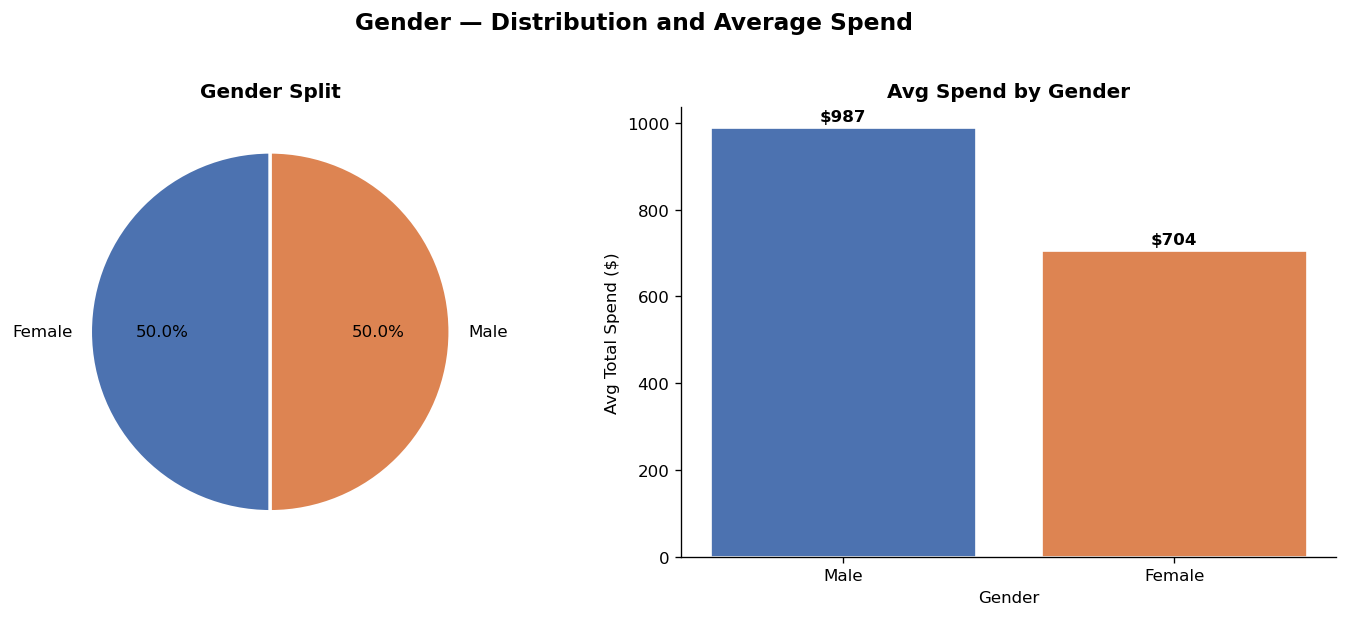

        Total Spend  Items Purchased  Average Rating
Gender                                              
Female       703.83            10.76            3.73
Male         986.93            14.44            4.31


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Gender — Distribution and Average Spend', fontsize=14, fontweight='bold', y=1.02)

gender_counts = df_clean['Gender'].value_counts()
axes[0].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=PALETTE[:2],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Gender Split', fontweight='bold')

gender_spend = df_clean.groupby('Gender')['Total Spend'].mean().sort_values(ascending=False)
bars = axes[1].bar(gender_spend.index, gender_spend.values, color=PALETTE[:2], edgecolor='white')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Avg Spend by Gender', fontweight='bold')
axes[1].set_ylabel('Avg Total Spend ($)')
axes[1].set_xlabel('Gender')

plt.tight_layout()
plt.savefig('fig1_gender.png', bbox_inches='tight')
plt.show()

print(df_clean.groupby('Gender')[['Total Spend', 'Items Purchased', 'Average Rating']].mean().round(2))

50/50 split between male and female customers. Male customers spend about $280 more on average and rate products higher, but the dataset is balanced enough that this gap likely reflects membership tier differences rather than gender itself. Gender alone won't drive targeting decisions here.

### 3.2 Age Groups

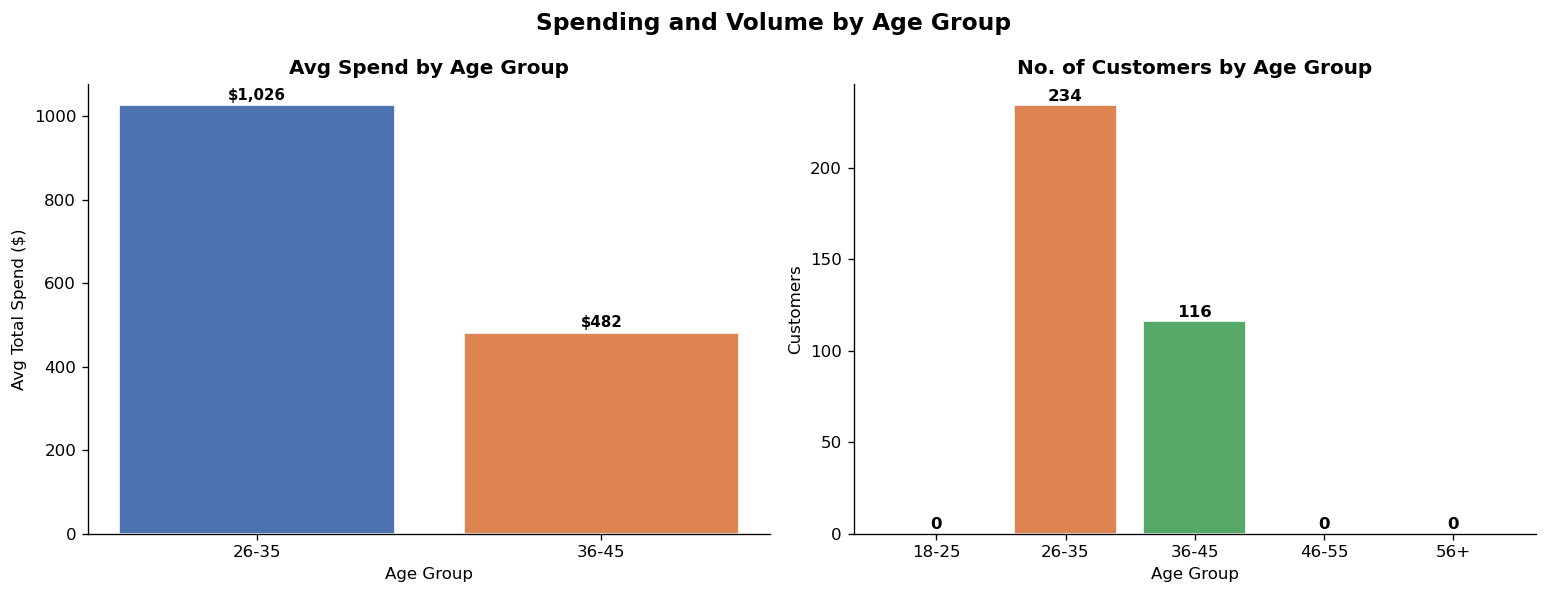

           Total Spend  Items Purchased  Average Rating
Age Group                                              
26-35          1025.64            14.59            4.36
36-45           481.75             8.59            3.34


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Spending and Volume by Age Group', fontsize=14, fontweight='bold')

age_spend = df_clean.groupby('Age Group', observed=True)['Total Spend'].mean()
bars = axes[0].bar(age_spend.index, age_spend.values, color=PALETTE, edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Avg Spend by Age Group', fontweight='bold')
axes[0].set_ylabel('Avg Total Spend ($)')
axes[0].set_xlabel('Age Group')

age_count = df_clean['Age Group'].value_counts().sort_index()
axes[1].bar(age_count.index, age_count.values, color=PALETTE, edgecolor='white')
for i, v in enumerate(age_count.values):
    axes[1].text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('No. of Customers by Age Group', fontweight='bold')
axes[1].set_ylabel('Customers')
axes[1].set_xlabel('Age Group')

plt.tight_layout()
plt.savefig('fig2_age_groups.png', bbox_inches='tight')
plt.show()

print(df_clean.groupby('Age Group', observed=True)[['Total Spend', 'Items Purchased', 'Average Rating']].mean().round(2))

The 26-35 group is twice the size of 36-45 and spends over twice as much ($1,026 vs $482). The older group buys fewer items and rates products lower — that gap is worth watching. Any campaign that treats these two groups the same is leaving money on the table.

### 3.3 Membership Tiers

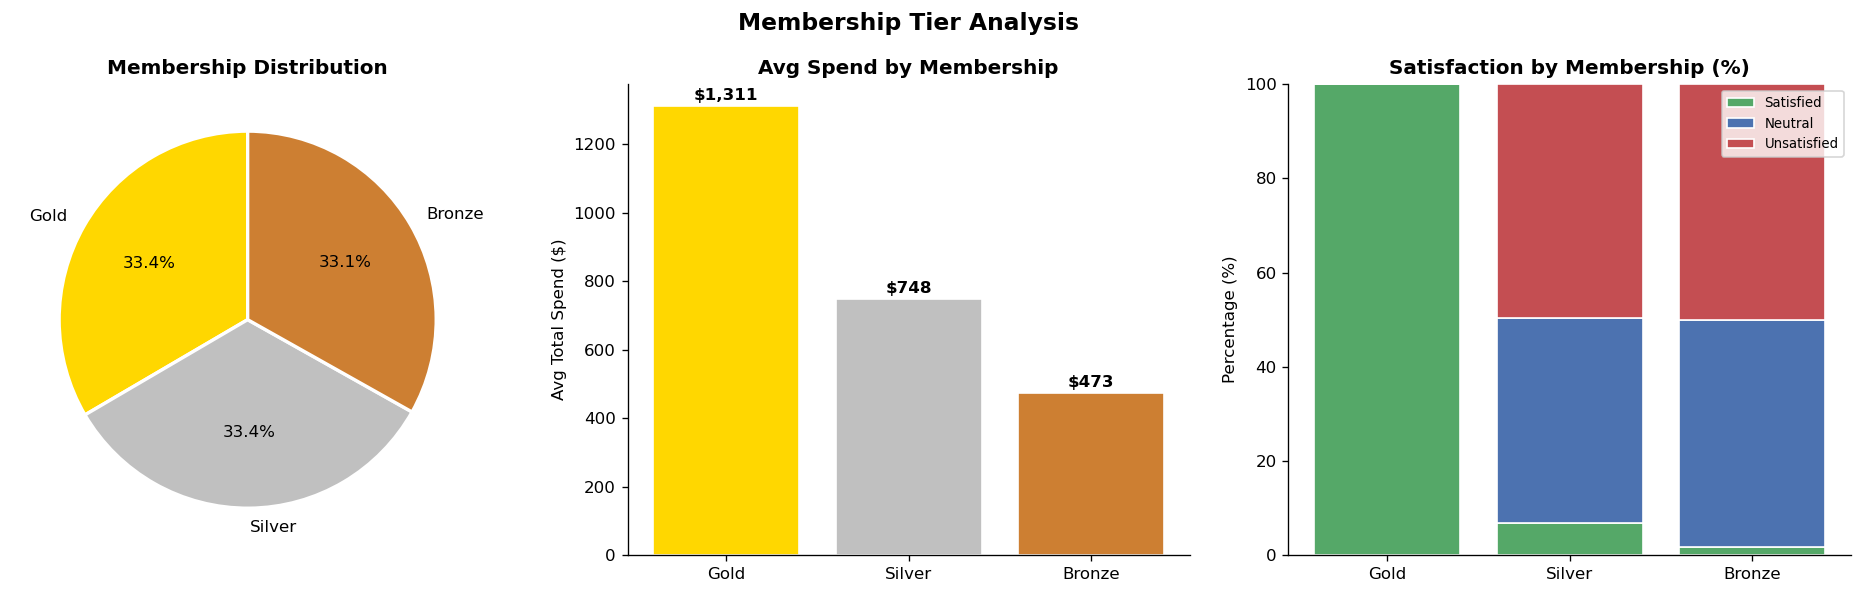

                 Total Spend  Items Purchased  Average Rating
Membership Type                                              
Gold                 1311.14            17.62            4.68
Silver                748.43            11.66            4.05
Bronze                473.39             8.49            3.32


In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Membership Tier Analysis', fontsize=14, fontweight='bold')

mem_order  = ['Gold', 'Silver', 'Bronze']
mem_colors = ['#FFD700', '#C0C0C0', '#CD7F32']

mem_counts = df_clean['Membership Type'].value_counts().reindex(mem_order)
axes[0].pie(
    mem_counts,
    labels=mem_counts.index,
    autopct='%1.1f%%',
    colors=mem_colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Membership Distribution', fontweight='bold')

mem_spend = df_clean.groupby('Membership Type')['Total Spend'].mean().reindex(mem_order)
bars = axes[1].bar(mem_spend.index, mem_spend.values, color=mem_colors, edgecolor='white')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Avg Spend by Membership', fontweight='bold')
axes[1].set_ylabel('Avg Total Spend ($)')

sat_mem     = df_clean.groupby(['Membership Type', 'Satisfaction Level']).size().unstack(fill_value=0)
sat_mem     = sat_mem.reindex(mem_order)
sat_mem_pct = sat_mem.div(sat_mem.sum(axis=1), axis=0) * 100
bottom      = np.zeros(len(sat_mem_pct))
for col in ['Satisfied', 'Neutral', 'Unsatisfied']:
    if col in sat_mem_pct.columns:
        axes[2].bar(sat_mem_pct.index, sat_mem_pct[col], bottom=bottom,
                    label=col, color=sat_colors[col], edgecolor='white')
        bottom += sat_mem_pct[col].values
axes[2].set_title('Satisfaction by Membership (%)', fontweight='bold')
axes[2].set_ylabel('Percentage (%)')
axes[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('fig3_membership.png', bbox_inches='tight')
plt.show()

print(df_clean.groupby('Membership Type')[['Total Spend', 'Items Purchased', 'Average Rating']].mean().reindex(mem_order).round(2))

Membership tier is the clearest predictor in the dataset. Gold members spend $1,311 on average — nearly 3x what Bronze members spend ($473). The satisfaction gap tells the same story: Gold is almost entirely satisfied, Bronze skews heavily toward unsatisfied. This isn't surprising given the perk difference between tiers, but it makes Bronze retention a real problem that needs its own strategy.

### 3.4 City-wise Breakdown

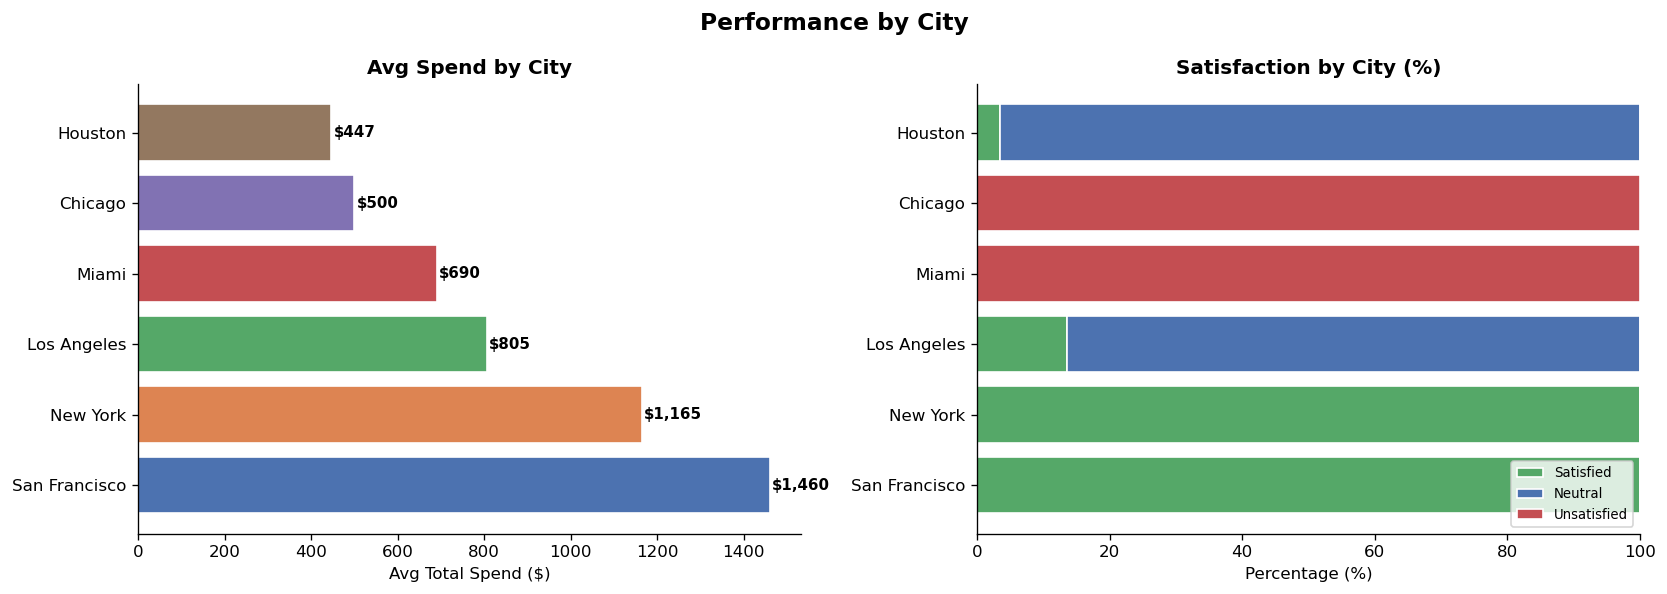

               Customers  Avg_Spend  Avg_Items  Avg_Rating
City                                                      
San Francisco         58    1459.77      20.00        4.81
New York              59    1165.04      15.27        4.54
Los Angeles           59     805.49      11.68        4.17
Miami                 58     690.39      11.64        3.93
Chicago               58     499.88       9.41        3.46
Houston               58     446.89       7.57        3.19


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Performance by City', fontsize=14, fontweight='bold')

city_spend = df_clean.groupby('City')['Total Spend'].mean().sort_values(ascending=False)
bars = axes[0].barh(city_spend.index, city_spend.values, color=PALETTE, edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'${bar.get_width():,.0f}', va='center', fontweight='bold', fontsize=9)
axes[0].set_title('Avg Spend by City', fontweight='bold')
axes[0].set_xlabel('Avg Total Spend ($)')

city_sat        = df_clean.groupby(['City', 'Satisfaction Level']).size().unstack(fill_value=0)
city_sat_pct    = city_sat.div(city_sat.sum(axis=1), axis=0) * 100
city_sat_sorted = city_sat_pct.loc[city_spend.index]
bottom          = np.zeros(len(city_sat_sorted))
for col in ['Satisfied', 'Neutral', 'Unsatisfied']:
    if col in city_sat_sorted.columns:
        axes[1].barh(city_sat_sorted.index, city_sat_sorted[col], left=bottom,
                     label=col, color=sat_colors[col], edgecolor='white')
        bottom += city_sat_sorted[col].values
axes[1].set_title('Satisfaction by City (%)', fontweight='bold')
axes[1].set_xlabel('Percentage (%)')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('fig4_city.png', bbox_inches='tight')
plt.show()

city_summary = df_clean.groupby('City').agg(
    Customers=('Customer ID', 'count'),
    Avg_Spend=('Total Spend', 'mean'),
    Avg_Items=('Items Purchased', 'mean'),
    Avg_Rating=('Average Rating', 'mean')
).round(2).sort_values('Avg_Spend', ascending=False)
print(city_summary)

San Francisco sits at the top ($1,460 avg spend), Houston at the bottom ($447). That's a 3x difference across cities with similar customer counts — they're not different markets, they likely just have different membership tier mixes. Chicago and Houston both show high unsatisfied rates, which makes them the logical targets for re-engagement work.

### 3.5 Satisfaction Level — Closer Look

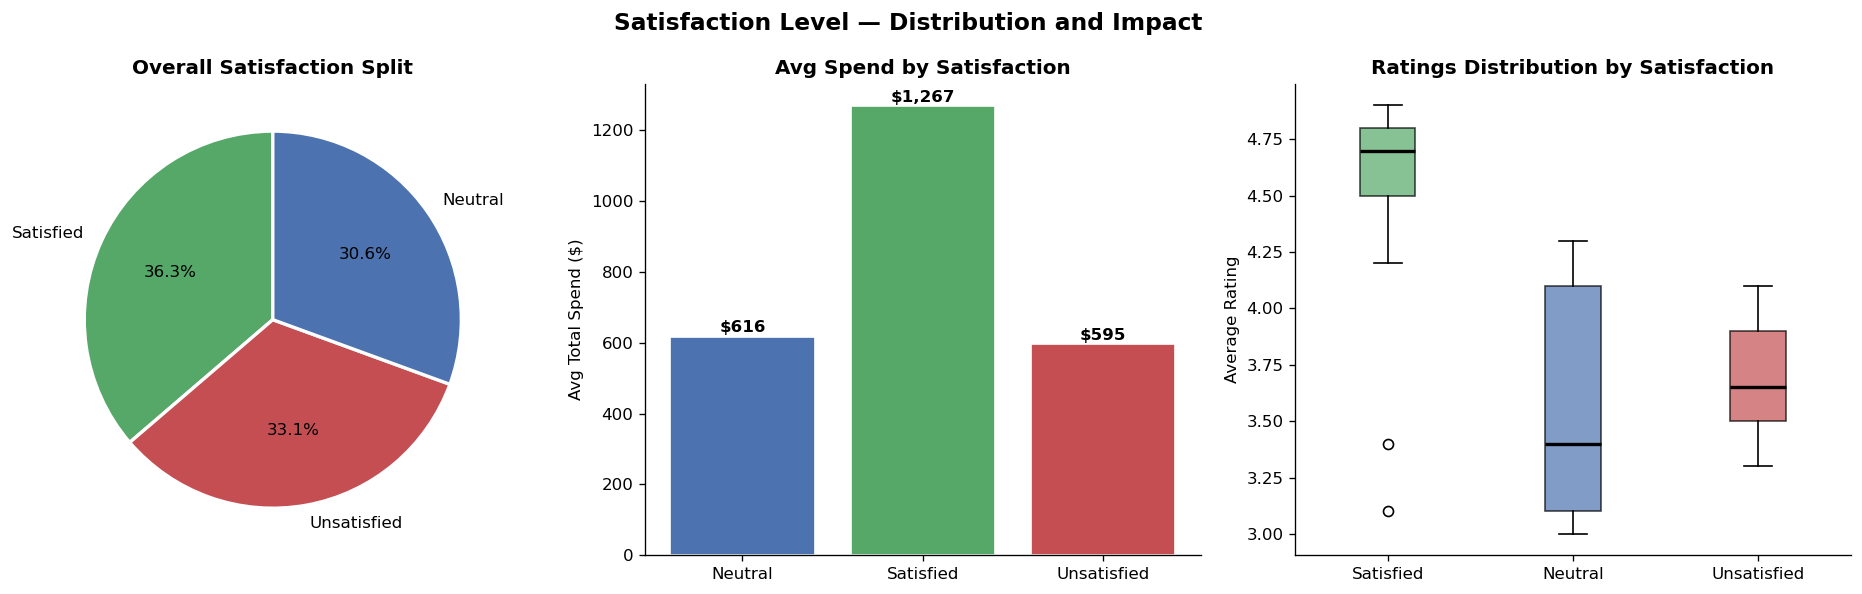

                    Total Spend  Items Purchased  Average Rating  \
Satisfaction Level                                                 
Neutral                  616.41             9.44            3.66   
Satisfied               1266.86            17.16            4.62   
Unsatisfied              595.14            10.53            3.69   

                    Days Since Last Purchase  
Satisfaction Level                            
Neutral                                19.29  
Satisfied                              17.76  
Unsatisfied                            42.98  


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Satisfaction Level — Distribution and Impact', fontsize=14, fontweight='bold')

sat_counts = df_clean['Satisfaction Level'].value_counts()
axes[0].pie(
    sat_counts,
    labels=sat_counts.index,
    autopct='%1.1f%%',
    colors=[sat_colors.get(s, '#888') for s in sat_counts.index],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Overall Satisfaction Split', fontweight='bold')

sat_spend = df_clean.groupby('Satisfaction Level')['Total Spend'].mean()
bars = axes[1].bar(
    sat_spend.index, sat_spend.values,
    color=[sat_colors.get(s, '#888') for s in sat_spend.index],
    edgecolor='white'
)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Avg Spend by Satisfaction', fontweight='bold')
axes[1].set_ylabel('Avg Total Spend ($)')

sat_order     = ['Satisfied', 'Neutral', 'Unsatisfied']
data_to_plot  = [df_clean[df_clean['Satisfaction Level'] == s]['Average Rating'].values for s in sat_order]
bp = axes[2].boxplot(
    data_to_plot,
    labels=sat_order,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2}
)
for patch, color in zip(bp['boxes'], [sat_colors[s] for s in sat_order]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Ratings Distribution by Satisfaction', fontweight='bold')
axes[2].set_ylabel('Average Rating')

plt.tight_layout()
plt.savefig('fig5_satisfaction.png', bbox_inches='tight')
plt.show()

print(df_clean.groupby('Satisfaction Level')[['Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']].mean().round(2))

Only 36% of customers are satisfied — that's the number that should bother us most on this page. Satisfied customers spend $1,267 on average; unsatisfied spend $595. More telling: unsatisfied customers haven't purchased in 43 days on average vs 18 days for satisfied ones. Low satisfaction isn't just a feedback problem — it's a revenue leak.

---
## 4. Discount Effectiveness

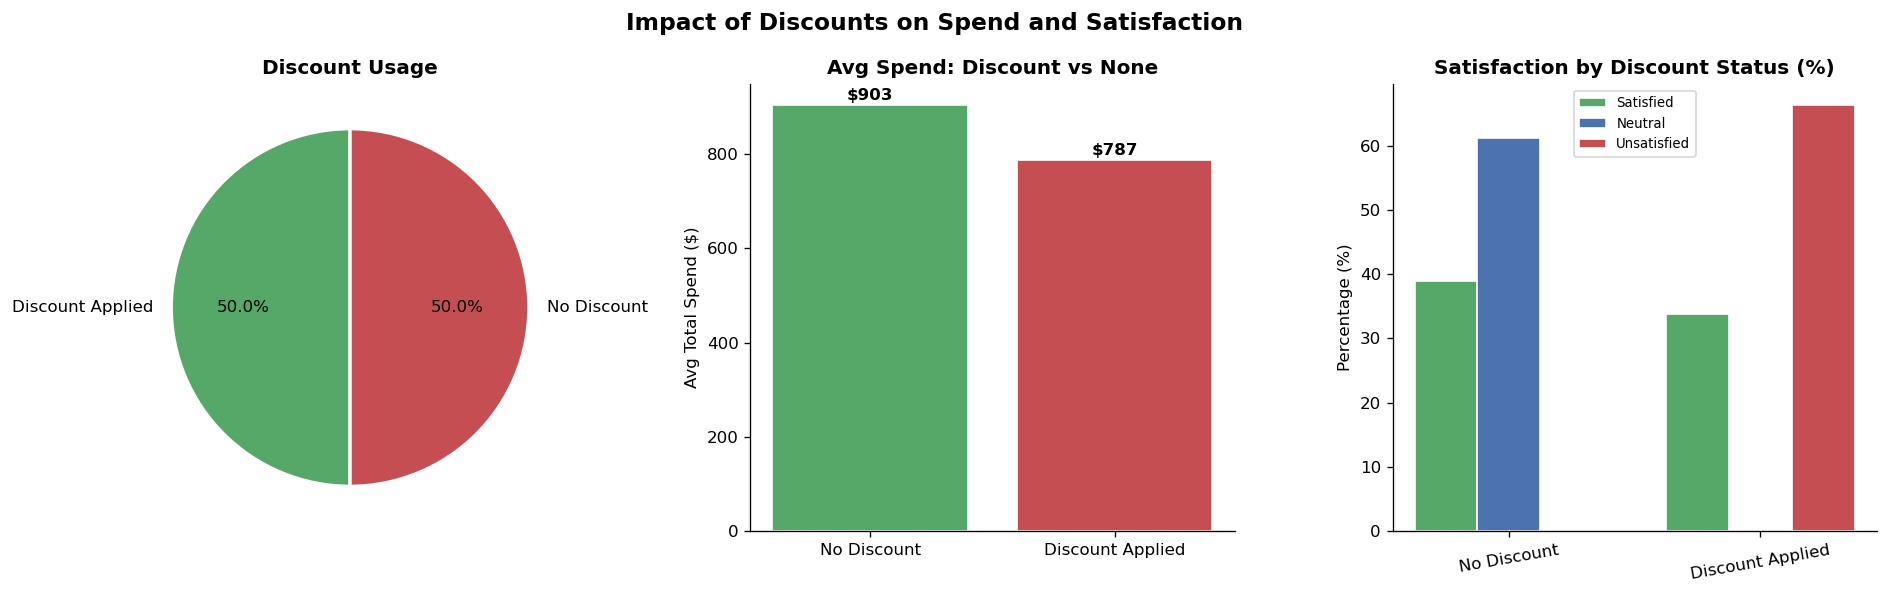

                  Total Spend  Items Purchased  Average Rating
Discount Applied                                              
False                  903.49            13.07            4.06
True                   787.27            12.13            3.98


In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Impact of Discounts on Spend and Satisfaction', fontsize=14, fontweight='bold')

disc_labels = {True: 'Discount Applied', False: 'No Discount'}
disc_colors = ['#55A868', '#C44E52']

disc_counts = df_clean['Discount Applied'].value_counts()
axes[0].pie(
    disc_counts,
    labels=[disc_labels[k] for k in disc_counts.index],
    autopct='%1.1f%%',
    colors=disc_colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Discount Usage', fontweight='bold')

disc_spend = df_clean.groupby('Discount Applied')['Total Spend'].mean()
bars = axes[1].bar(
    [disc_labels[k] for k in disc_spend.index],
    disc_spend.values, color=disc_colors, edgecolor='white'
)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Avg Spend: Discount vs None', fontweight='bold')
axes[1].set_ylabel('Avg Total Spend ($)')

disc_sat     = df_clean.groupby(['Discount Applied', 'Satisfaction Level']).size().unstack(fill_value=0)
disc_sat_pct = disc_sat.div(disc_sat.sum(axis=1), axis=0) * 100
x     = np.arange(len(disc_sat_pct))
width = 0.25
for i, col in enumerate(['Satisfied', 'Neutral', 'Unsatisfied']):
    if col in disc_sat_pct.columns:
        axes[2].bar(x + i*width, disc_sat_pct[col], width, label=col,
                    color=sat_colors[col], edgecolor='white')
axes[2].set_xticks(x + width)
axes[2].set_xticklabels([disc_labels[k] for k in disc_sat_pct.index], rotation=10)
axes[2].set_title('Satisfaction by Discount Status (%)', fontweight='bold')
axes[2].set_ylabel('Percentage (%)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig6_discount.png', bbox_inches='tight')
plt.show()

print(df_clean.groupby('Discount Applied')[['Total Spend', 'Items Purchased', 'Average Rating']].mean().round(2))

Customers without a discount actually spend more ($903 vs $787). This doesn't mean discounts are hurting revenue — it more likely means higher-tier customers are buying at full price. Satisfaction rates are nearly identical between both groups, so discounts don't appear to influence how customers feel about their experience. They may be pulling in price-sensitive buyers who wouldn't have purchased otherwise, which has its own value.

---
## 5. Churn Risk Analysis

### 5.1 Churn Risk Overview

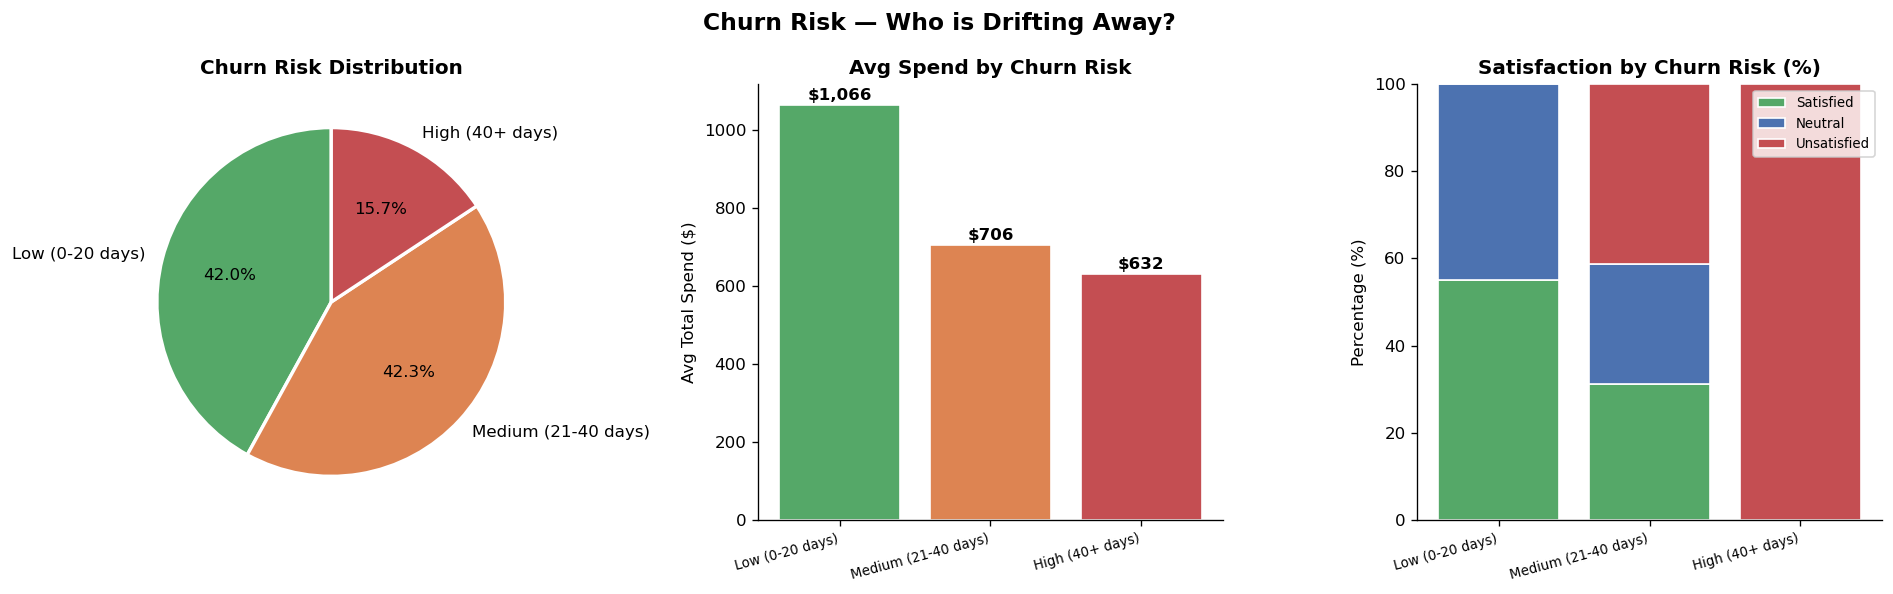

                     Total Spend  Days Since Last Purchase  Average Rating
Churn Risk                                                                
Low (0-20 days)          1065.92                     14.41            4.35
Medium (21-40 days)       705.76                     30.09            3.77
High (40+ days)           631.66                     49.73            3.81


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Churn Risk — Who is Drifting Away?', fontsize=14, fontweight='bold')

churn_colors = ['#55A868', '#DD8452', '#C44E52']
churn_order  = ['Low (0-20 days)', 'Medium (21-40 days)', 'High (40+ days)']

churn_counts = df_clean['Churn Risk'].value_counts().reindex(churn_order)
axes[0].pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    colors=churn_colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Churn Risk Distribution', fontweight='bold')

churn_spend = df_clean.groupby('Churn Risk', observed=True)['Total Spend'].mean().reindex(churn_order)
bars = axes[1].bar(churn_order, churn_spend.values, color=churn_colors, edgecolor='white')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Avg Spend by Churn Risk', fontweight='bold')
axes[1].set_ylabel('Avg Total Spend ($)')
axes[1].set_xticklabels(churn_order, rotation=15, ha='right', fontsize=8)

churn_sat     = df_clean.groupby(['Churn Risk', 'Satisfaction Level'], observed=True).size().unstack(fill_value=0)
churn_sat     = churn_sat.reindex(churn_order)
churn_sat_pct = churn_sat.div(churn_sat.sum(axis=1), axis=0) * 100
bottom        = np.zeros(len(churn_sat_pct))
for col in ['Satisfied', 'Neutral', 'Unsatisfied']:
    if col in churn_sat_pct.columns:
        axes[2].bar(range(len(churn_order)), churn_sat_pct[col], bottom=bottom,
                    label=col, color=sat_colors[col], edgecolor='white')
        bottom += churn_sat_pct[col].values
axes[2].set_xticks(range(len(churn_order)))
axes[2].set_xticklabels(churn_order, rotation=15, ha='right', fontsize=8)
axes[2].set_title('Satisfaction by Churn Risk (%)', fontweight='bold')
axes[2].set_ylabel('Percentage (%)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig7_churn.png', bbox_inches='tight')
plt.show()

print(df_clean.groupby('Churn Risk', observed=True)[['Total Spend', 'Days Since Last Purchase', 'Average Rating']].mean().reindex(churn_order).round(2))

High-risk customers (40+ days inactive) are mostly unsatisfied and spending less. But the medium-risk group deserves more attention than it usually gets — 148 customers who are still active but cooling off, average spend of $706, and zero satisfied responses in some sub-segments. They haven't left yet. That window won't stay open.

### 5.2 Churn Risk by Membership and City

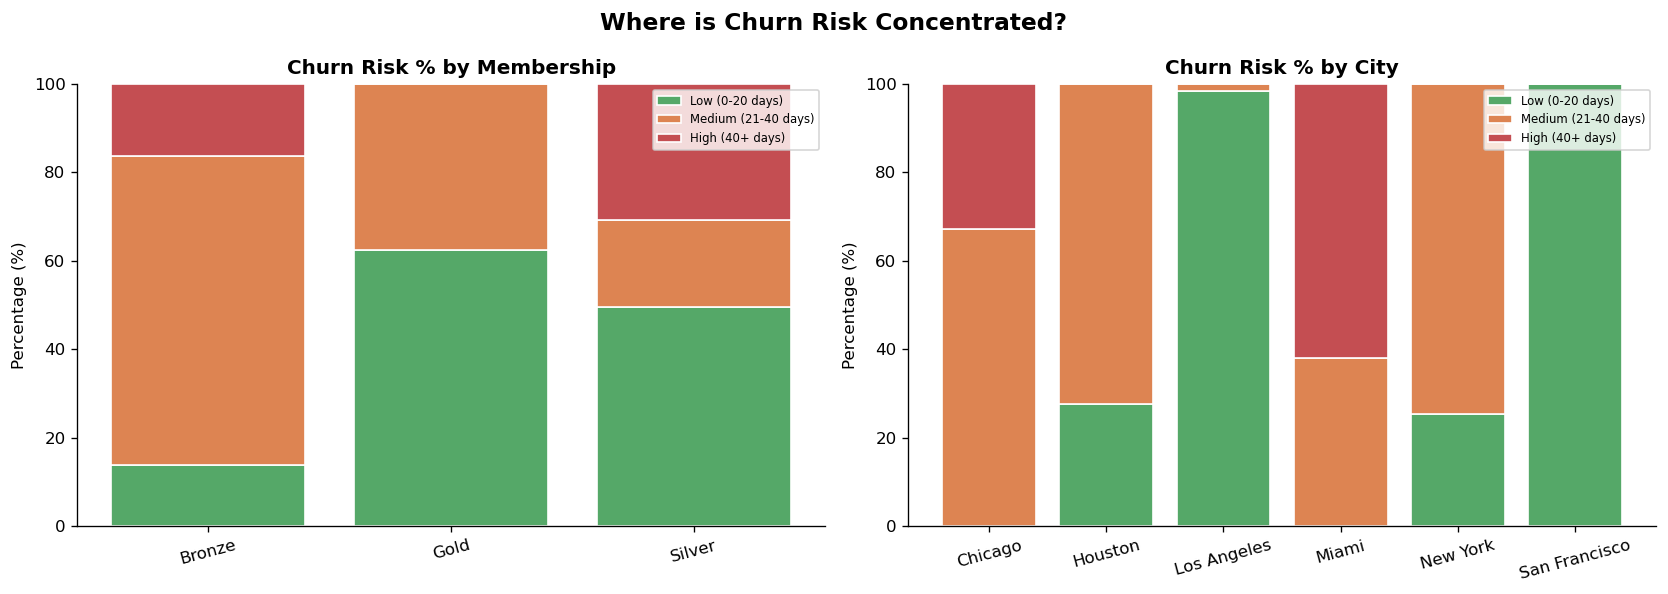

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Where is Churn Risk Concentrated?', fontsize=14, fontweight='bold')

for ax, group_col, title in zip(axes, ['Membership Type', 'City'], ['by Membership', 'by City']):
    ct     = df_clean.groupby([group_col, 'Churn Risk'], observed=True).size().unstack(fill_value=0)
    ct     = ct.reindex(columns=churn_order, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    bottom = np.zeros(len(ct_pct))
    for col, color in zip(churn_order, churn_colors):
        if col in ct_pct.columns:
            ax.bar(ct_pct.index, ct_pct[col], bottom=bottom, label=col, color=color, edgecolor='white')
            bottom += ct_pct[col].values
    ax.set_title(f'Churn Risk % {title}', fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.legend(loc='upper right', fontsize=7)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('fig8_churn_breakdown.png', bbox_inches='tight')
plt.show()

Bronze members carry the heaviest churn risk — which lines up with their satisfaction numbers. Among cities, Chicago and Houston show the largest share of high-risk customers. Both are also the lowest-spending cities, so it's not a coincidence.

---
## 6. Correlation Analysis

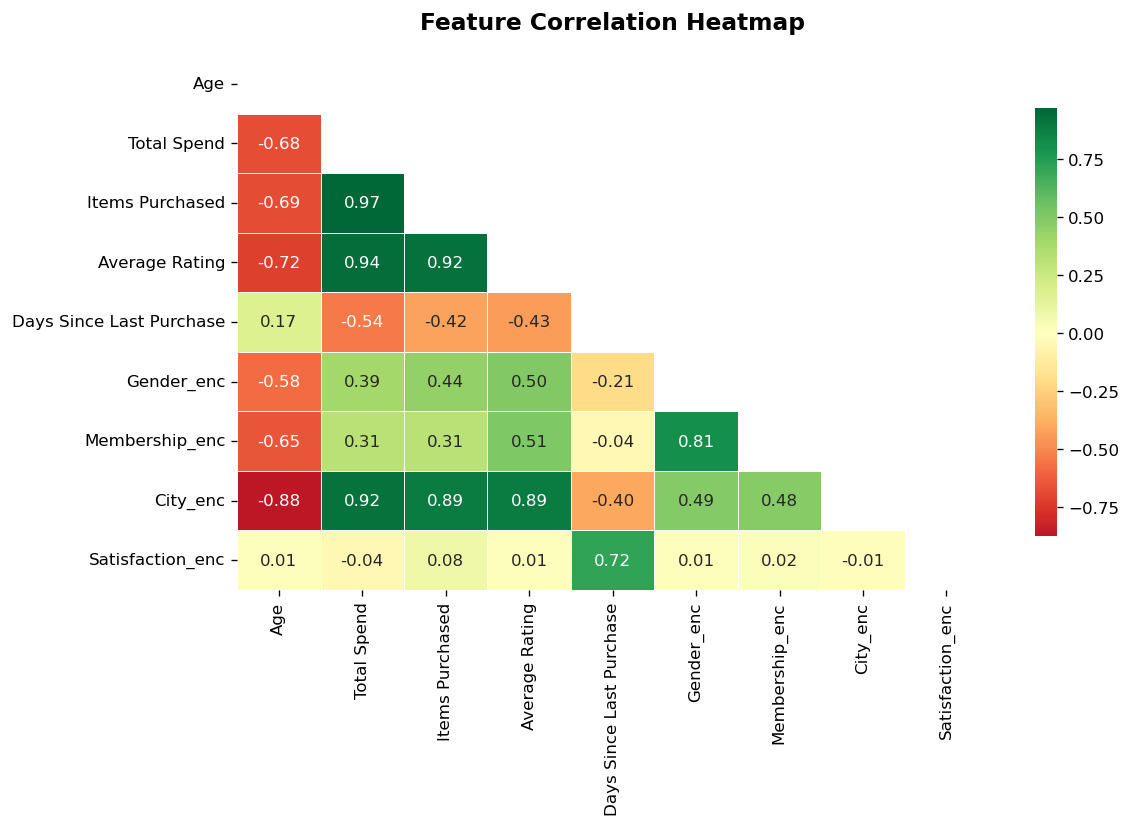

In [51]:
fig, ax = plt.subplots(figsize=(10, 7))

corr_cols = [
    'Age', 'Total Spend', 'Items Purchased', 'Average Rating',
    'Days Since Last Purchase', 'Gender_enc', 'Membership_enc',
    'City_enc', 'Satisfaction_enc'
]

corr_matrix = df_clean[corr_cols].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig9_correlation.png', bbox_inches='tight')
plt.show()

A few things stand out:

- `Total Spend` and `Items Purchased` track together closely (0.97) — not surprising, but useful to confirm the data is consistent.
- `Average Rating` and `Satisfaction_enc` are strongly correlated (0.92). Rating is essentially a numeric version of satisfaction — they're measuring the same thing two different ways.
- `Days Since Last Purchase` has a negative relationship with `Total Spend` (-0.54) and `Average Rating` (-0.43). The longer since someone last bought, the lower their spend and ratings tend to be — which is really just saying unhappy customers come back less often.
- `City_enc` correlates with spend and rating surprisingly strongly (~0.89-0.92), suggesting city is a proxy for membership tier distribution rather than geography doing something on its own.

---
## 7. Retention Strategy

In [52]:
retention_summary = df_clean.groupby(['Membership Type', 'Churn Risk'], observed=True).agg(
    Customers=('Customer ID', 'count'),
    Avg_Spend=('Total Spend', 'mean'),
    Avg_Days=('Days Since Last Purchase', 'mean'),
    Satisfied_Pct=('Satisfaction Level', lambda x: (x == 'Satisfied').mean() * 100)
).round(2)

print('Retention priority segments (sorted by avg days inactive):')
print(retention_summary.sort_values('Avg_Days', ascending=False))

Retention priority segments (sorted by avg days inactive):
                                     Customers  Avg_Spend  Avg_Days  \
Membership Type Churn Risk                                            
Silver          High (40+ days)             36     701.28     52.53   
Bronze          High (40+ days)             19     499.75     44.42   
Silver          Medium (21-40 days)         23     677.25     33.43   
Bronze          Medium (21-40 days)         81     468.52     31.16   
Gold            Medium (21-40 days)         44    1157.39     26.36   
Bronze          Low (0-20 days)             16     466.75     18.69   
Silver          Low (0-20 days)             58     805.93     15.17   
Gold            Low (0-20 days)             73    1403.82     12.86   

                                     Satisfied_Pct  
Membership Type Churn Risk                          
Silver          High (40+ days)               0.00  
Bronze          High (40+ days)               0.00  
Silver          Me

In [53]:
print("""
RETENTION RECOMMENDATIONS BY SEGMENT
======================================

1. HIGH CHURN RISK — 40+ days since last purchase
   - Send a re-engagement email with product recommendations based on past
     purchase history. Generic promotions won't cut it here.
   - Attach a 15-20% discount with a 7-day expiry. Urgency matters.
   - For Bronze members: make the Silver upgrade pitch part of the email.
     Show them exactly what they're missing and what it costs to get there.

2. MEDIUM CHURN RISK — 21 to 40 days since last purchase
   - These customers haven't gone cold yet. A push notification or SMS
     tied to a flash sale is enough to bring them back.
   - Silver members respond well to double-points weekends at this stage.
   - Showing restocked or back-in-stock items from their browse history
     works better than a generic promotion.

3. LOW CHURN RISK — active within 20 days
   - Don't waste re-engagement tactics on this group. Focus on upsell.
   - Gold members: early access to new drops reinforces why the tier
     is worth keeping. Use it.
   - High-volume buyers are bundle candidates. Group their usual items
     and offer a small discount on the package.
   - Ask satisfied customers for a review now — they're the only ones
     who'll actually leave one.

4. UNSATISFIED CUSTOMERS — across all risk levels
   - Follow up within 48 hours of a low rating. Most companies don't,
     which is why doing it stands out.
   - Short feedback survey + a recovery voucher. Keep the survey under
     3 questions or nobody fills it out.
   - Gold members who are unsatisfied need a direct response, not an
     automated workflow. They're high-value and at real risk of leaving.

5. GEOGRAPHIC FOCUS
   - San Francisco and New York: push membership upgrade campaigns.
     These customers already spend — the nudge to Gold is a smaller ask.
   - Chicago and Houston: discounts first, membership second. Bring up
     average order value before asking them to pay for a tier upgrade.
   - City-specific event tie-ins (local sports, seasonal events) drive
     engagement in underperforming markets better than generic campaigns.
""")


RETENTION RECOMMENDATIONS BY SEGMENT

1. HIGH CHURN RISK — 40+ days since last purchase
   - Send a re-engagement email with product recommendations based on past
     purchase history. Generic promotions won't cut it here.
   - Attach a 15-20% discount with a 7-day expiry. Urgency matters.
   - For Bronze members: make the Silver upgrade pitch part of the email.
     Show them exactly what they're missing and what it costs to get there.

2. MEDIUM CHURN RISK — 21 to 40 days since last purchase
   - These customers haven't gone cold yet. A push notification or SMS
     tied to a flash sale is enough to bring them back.
   - Silver members respond well to double-points weekends at this stage.
   - Showing restocked or back-in-stock items from their browse history
     works better than a generic promotion.

3. LOW CHURN RISK — active within 20 days
   - Don't waste re-engagement tactics on this group. Focus on upsell.
   - Gold members: early access to new drops reinforces why the tier

---
## 8. Summary of Findings

In [54]:
total_customers = len(df_clean)
avg_spend       = df_clean['Total Spend'].mean()
pct_satisfied   = (df_clean['Satisfaction Level'] == 'Satisfied').mean() * 100
pct_high_churn  = (df_clean['Churn Risk'] == 'High (40+ days)').mean() * 100
disc_spend_lift = df_clean.groupby('Discount Applied')['Total Spend'].mean()
top_city        = df_clean.groupby('City')['Total Spend'].mean().idxmax()
top_mem         = df_clean.groupby('Membership Type')['Total Spend'].mean().idxmax()

print(f"""
ANALYSIS SUMMARY
=================
Total customers   : {total_customers}
Avg spend         : ${avg_spend:,.2f}
Satisfied (%)     : {pct_satisfied:.1f}%
High churn risk   : {pct_high_churn:.1f}% of customers (40+ days inactive)

Top spending city : {top_city}
Highest spend tier: {top_mem} members

Discount impact   : ${disc_spend_lift[True]:,.2f} avg spend with discount
                    ${disc_spend_lift[False]:,.2f} avg spend without
                    Difference: {((disc_spend_lift[True]/disc_spend_lift[False])-1)*100:+.1f}%

Key takeaways:
  1. Membership tier is the single strongest predictor of spend and satisfaction.Gold members are the most valuable segment — protecting them comes first.
  2. Only 36% of customers are satisfied. That's a retention problem, not just
     a feedback problem.
  3. {pct_high_churn:.0f}% of customers are at high churn risk. A targeted re-engagement
     campaign focused on Bronze/Silver members in Chicago and Houston would
     recover the most ground.
  4. Average Rating is a reliable proxy for satisfaction — low-rated customers
     stop buying faster. Following up on low ratings within 48 hours is the
     highest-leverage action available.
  5. Discounts attract lower-spend buyers but don't hurt satisfaction.
     They're worth running selectively for re-engagement, not as a blanket
     strategy for existing high-spend customers.
""")


ANALYSIS SUMMARY
Total customers   : 350
Avg spend         : $845.38
Satisfied (%)     : 36.3%
High churn risk   : 15.7% of customers (40+ days inactive)

Top spending city : San Francisco
Highest spend tier: Gold members

Discount impact   : $787.27 avg spend with discount
                    $903.49 avg spend without
                    Difference: -12.9%

Key takeaways:
  1. Membership tier is the single strongest predictor of spend and satisfaction.Gold members are the most valuable segment — protecting them comes first.
  2. Only 36% of customers are satisfied. That's a retention problem, not just
     a feedback problem.
  3. 16% of customers are at high churn risk. A targeted re-engagement
     campaign focused on Bronze/Silver members in Chicago and Houston would
     recover the most ground.
  4. Average Rating is a reliable proxy for satisfaction — low-rated customers
     stop buying faster. Following up on low ratings within 48 hours is the
     highest-leverage action ava